## **Airline Passenger Satisfaction Classification Project ✈️**

# Part 1: Exploratory Data Analysis (EDA) and Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
air = pd.read_csv('data/airline_passenger_satisfaction.csv')

In [3]:
air.head()

,unnamed:_0,id,gender,customer_type,age,type_of_travel,class,flight_distance,inflight_wifi_service,departure_arrival_time_convenient,...,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25.0,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1.0,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0.0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11.0,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0.0,0.0,satisfied


**Identify Missing Values**

In [4]:
air.isna().sum()

unnamed:_0                           0
id                                   0
gender                               0
customer_type                        0
age                                  0
type_of_travel                       0
class                                0
flight_distance                      0
inflight_wifi_service                0
departure_arrival_time_convenient    0
ease_of_online_booking               0
gate_location                        0
food_and_drink                       0
online_boarding                      0
seat_comfort                         0
inflight_entertainment               0
on-board_service                     0
leg_room_service                     0
baggage_handling                     0
checkin_service                      0
inflight_service                     0
cleanliness                          0
departure_delay_in_minutes           0
arrival_delay_in_minutes             0
satisfaction                         0
dtype: int64

**Handle Missing Values**

In [5]:
air['arrival_delay_in_minutes'] = air['arrival_delay_in_minutes'].fillna(
    air['arrival_delay_in_minutes'].median()
)

In [6]:
air.dtypes

unnamed:_0                             int64
id                                     int64
gender                                object
customer_type                         object
age                                    int64
type_of_travel                        object
class                                 object
flight_distance                        int64
inflight_wifi_service                  int64
departure_arrival_time_convenient      int64
ease_of_online_booking                 int64
gate_location                          int64
food_and_drink                         int64
online_boarding                        int64
seat_comfort                           int64
inflight_entertainment                 int64
on-board_service                       int64
leg_room_service                       int64
baggage_handling                       int64
checkin_service                        int64
inflight_service                       int64
cleanliness                            int64
departure_

In [7]:
air.shape

(103904, 25)

## Numerical Feature Distributions

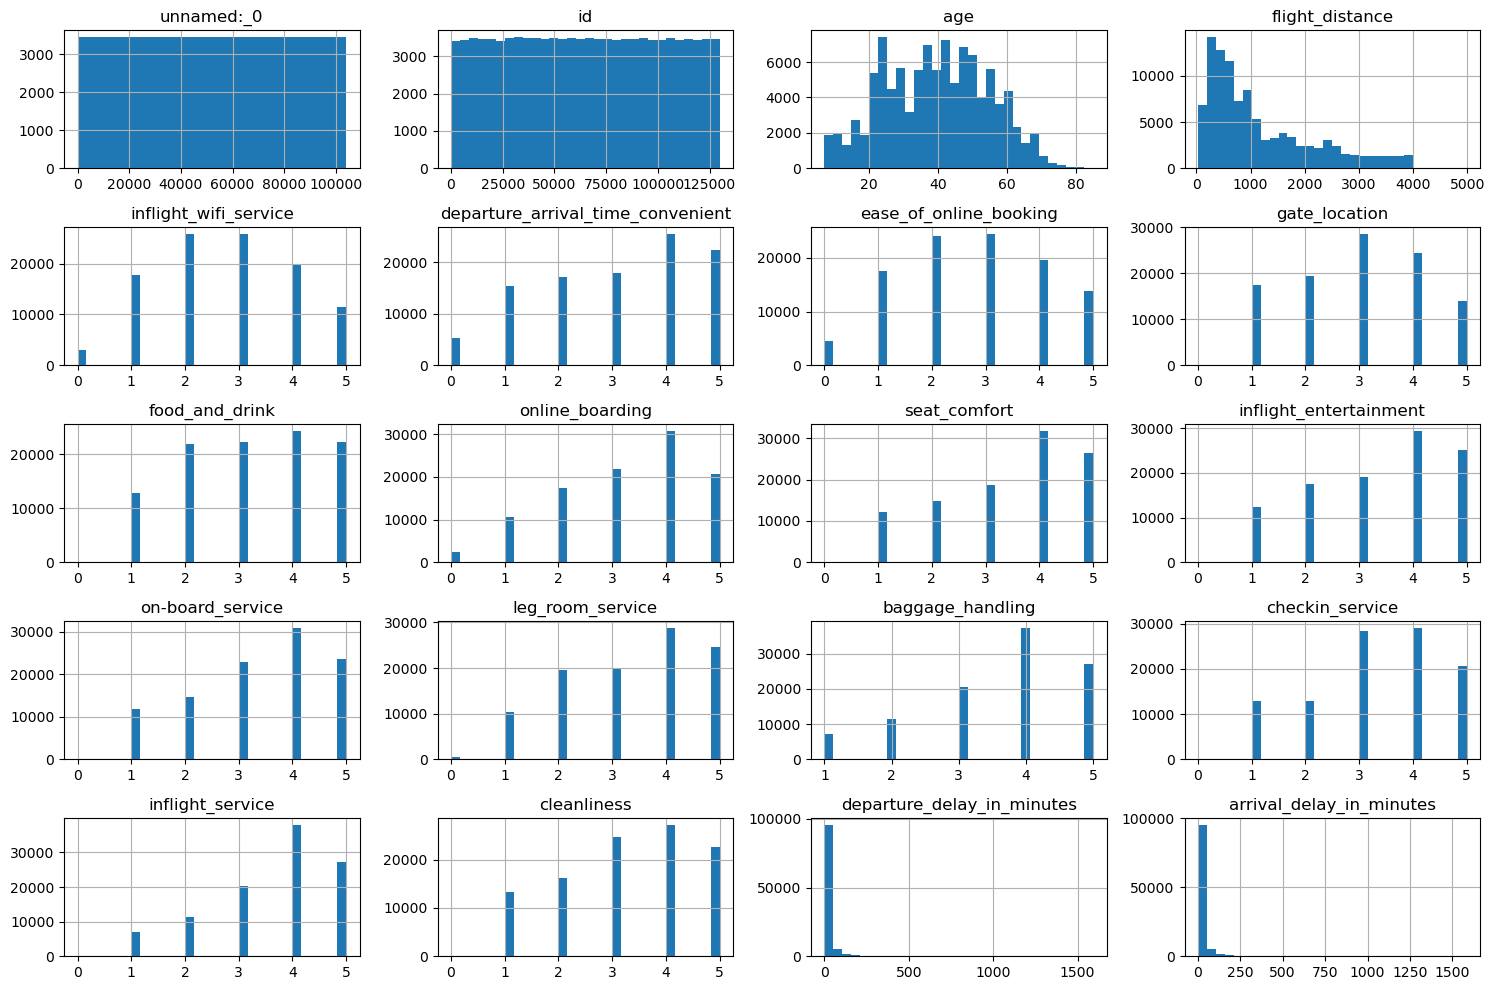

In [8]:
num_cols = air.select_dtypes(include=['int64','float64']).columns

air[num_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

## Important Numerical Variables

Age

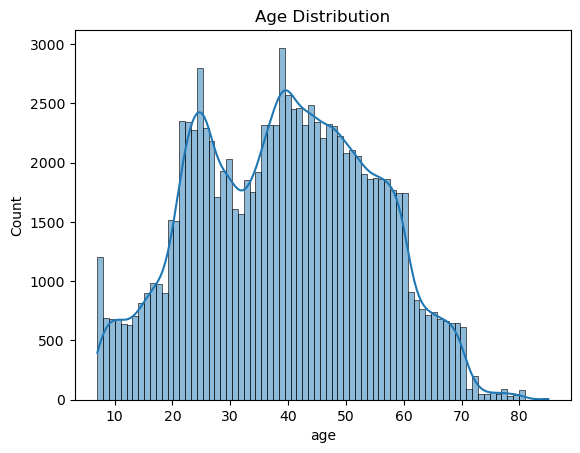

In [9]:
sns.histplot(air['age'], kde=True)
plt.title("Age Distribution")
plt.show()

Flight Distance

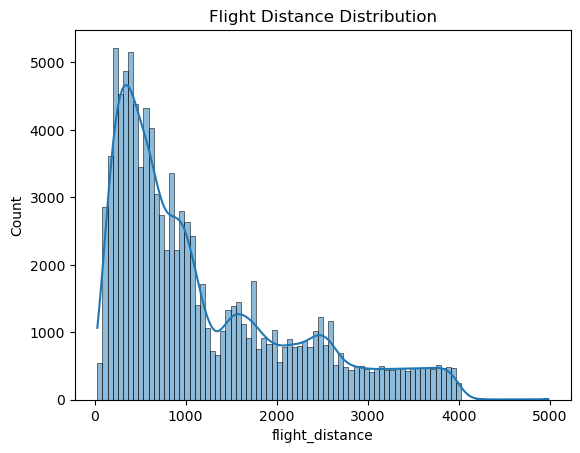

In [10]:
sns.histplot(air['flight_distance'], kde=True)
plt.title("Flight Distance Distribution")
plt.show()

Departure Delay

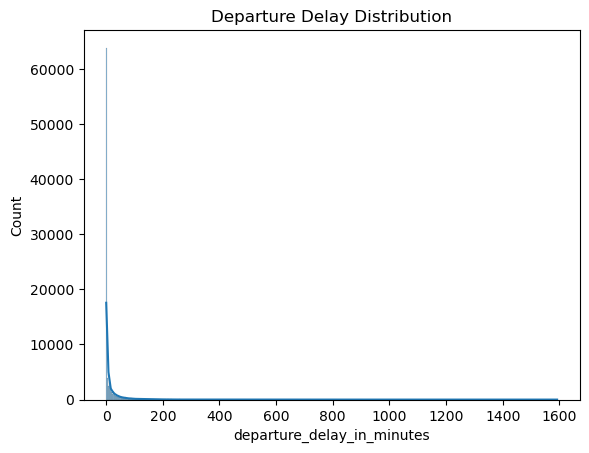

In [11]:
sns.histplot(air['departure_delay_in_minutes'], kde=True)
plt.title("Departure Delay Distribution")
plt.show()

**Detect Outliers**

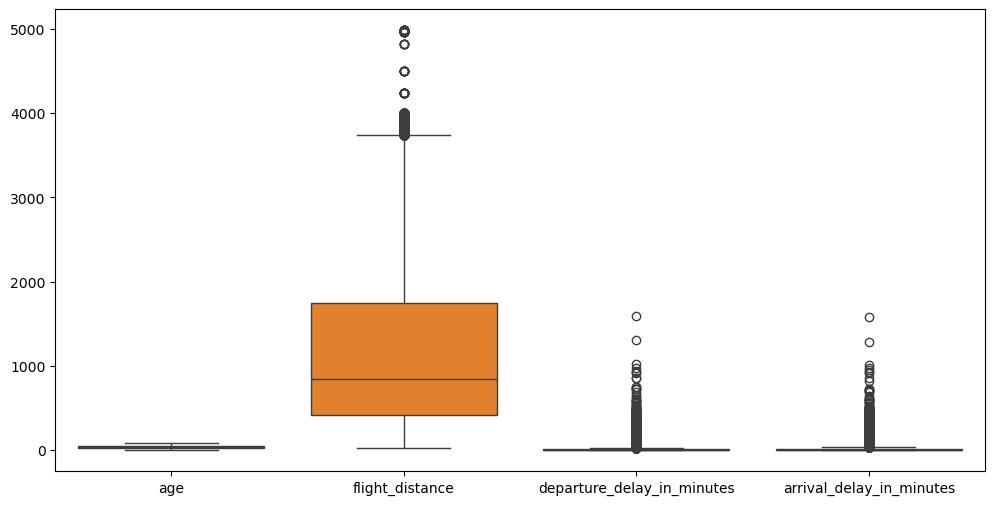

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(data=air[['age',
                      'flight_distance',
                      'departure_delay_in_minutes',
                      'arrival_delay_in_minutes']])

plt.show()

**Feature Engineering**

In [13]:
## Convert Target Variable

In [14]:
air['satisfaction'] = air['satisfaction'].map({
    'neutral or dissatisfied':0,
    'satisfied':1
})

**Create Total Delay Feature**

In [15]:
air['total_delay'] = air['departure_delay_in_minutes'] + air['arrival_delay_in_minutes']

**Drop unnamed column**

In [16]:
air.drop(columns=['id'], inplace=True)

**Encode Categorical Variables**

In [17]:
air = pd.get_dummies(air, drop_first=True)

**Correlation Heatmap**

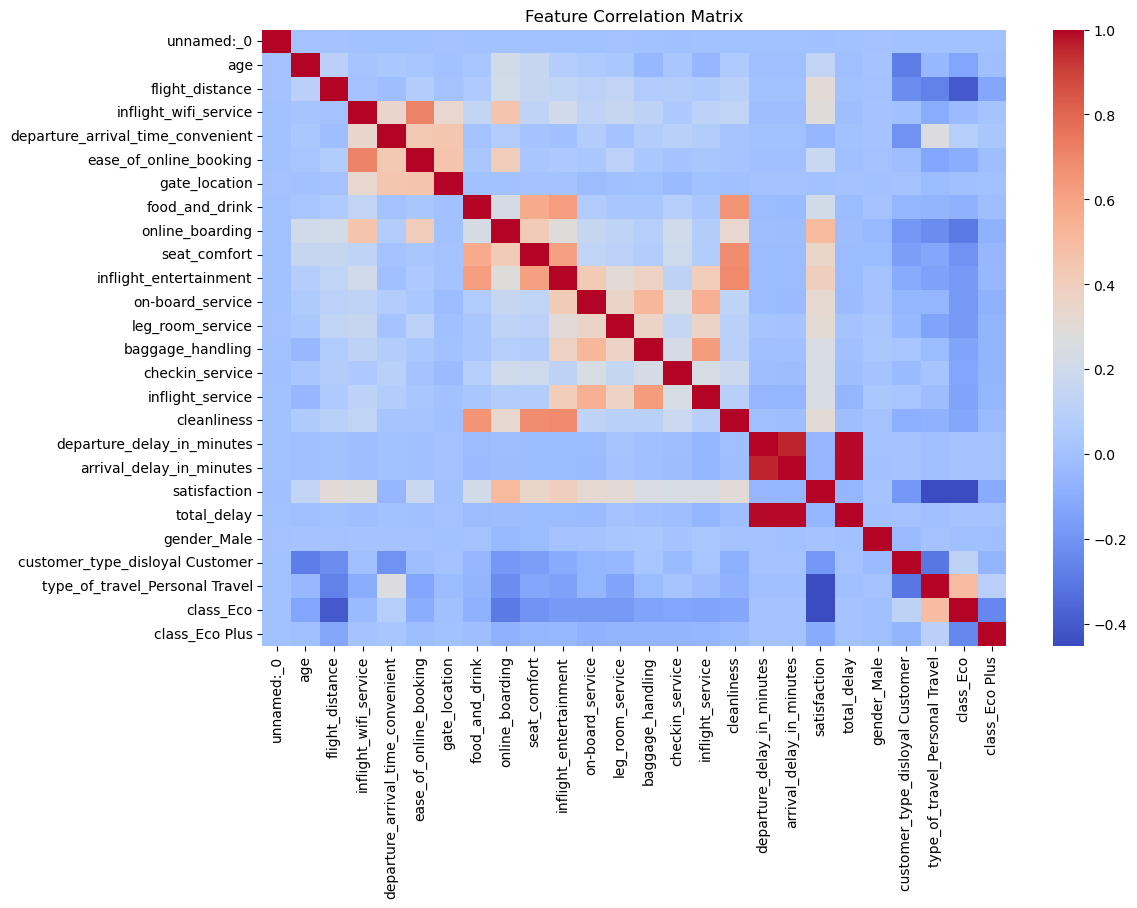

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(air.corr(), cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

Conclusion